# **Import some needed libraries**

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns  
import plotly.express as px 
from sklearn.preprocessing import LabelEncoder , RobustScaler
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# **Load data and explore it**

In [ ]:
df = pd.read_csv('egypt_yield_8400.csv')
df.head()

In [4]:
df.shape

(8400, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8400 entries, 0 to 8399
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   crop                     8400 non-null   object 
 1   area_feddans             8400 non-null   int64  
 2   region                   8400 non-null   object 
 3   season                   8400 non-null   object 
 4   soil_type                8400 non-null   object 
 5   yield_tonnes_per_feddan  8400 non-null   float64
 6   production_tonnes        8400 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 459.5+ KB


In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df.describe()

,area_feddans,yield_tonnes_per_feddan,production_tonnes
count,8400.000000,8400.000000,8400.000000
mean,272.524048,10.685971,3781.433369
std,243.787496,14.698584,8975.764201
min,1.000000,0.611000,1.000000
25%,94.000000,2.353500,318.700000
50%,185.000000,4.157500,908.200000
75%,393.000000,12.008250,2132.150000
max,999.000000,61.668860,61422.200000


In [8]:
num_col = df.select_dtypes(include=['int64','float64'])
print(num_col)

      area_feddans  yield_tonnes_per_feddan  production_tonnes
0              167                    3.840              641.3
1               56                   11.409              638.9
2                2                   12.822               25.6
3              357                    3.309             1181.3
4              178                    0.903              160.7
...            ...                      ...                ...
8395            63                   16.612             1046.6
8396            82                   16.814             1378.7
8397             6                   15.701               94.2
8398            18                    3.987               71.8
8399           189                    5.668             1071.3

[8400 rows x 3 columns]


In [9]:
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1 

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    print(f'---- {col} ----')
    print(f'{col} outliers : {outlier} , lp = {lower_bound} , up = {upper_bound}')
    print('---'*20)

---- area_feddans ----
area_feddans outliers : 328 , lp = -354.5 , up = 841.5
------------------------------------------------------------
---- yield_tonnes_per_feddan ----
yield_tonnes_per_feddan outliers : 1000 , lp = -12.128625 , up = 26.490375
------------------------------------------------------------
---- production_tonnes ----
production_tonnes outliers : 904 , lp = -2401.4750000000004 , up = 4852.325000000001
------------------------------------------------------------


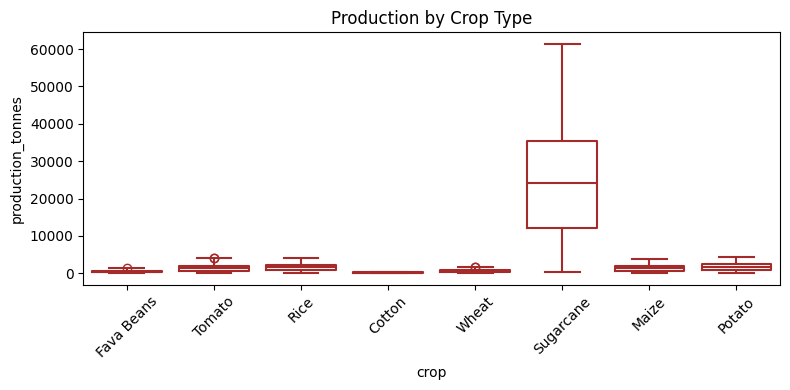

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(x='crop', y='production_tonnes', data=df,fill=False,color='brown')
sns.color_palette("dark:#5A9_r", as_cmap=True)
plt.xticks(rotation=45)
plt.title('Production by Crop Type')
plt.tight_layout()
plt.show()

In [11]:
df.groupby('crop')['production_tonnes'].describe()

,count,mean,std,min,25%,50%,75%,max
crop,,,,,,,,
Cotton,1000.0,157.762200,97.161531,1.0,79.200,145.70,227.575,436.6
Fava Beans,1000.0,475.247200,304.651457,3.7,218.900,453.35,697.725,1489.5
Maize,1100.0,1399.202000,869.187006,2.7,670.700,1329.90,2060.050,3935.3
Potato,1000.0,1671.004800,990.411450,11.6,832.125,1638.15,2386.050,4469.4
Rice,1000.0,1624.408900,975.101981,2.9,805.550,1599.85,2344.625,4076.1
Sugarcane,1000.0,24114.105900,14189.546679,280.9,12126.350,24073.65,35361.550,61422.2
Tomato,1100.0,1372.972000,876.513069,7.0,626.075,1292.50,1998.650,4185.7
Wheat,1200.0,560.099917,353.332545,1.5,276.475,515.35,810.925,1739.5


In [ ]:
outliers_df = df[df['production_tonnes'] > upper_bound]

print((outliers_df.head(10)))

         crop  area_feddans       region  season soil_type  \
14  Sugarcane           693  Upper_Egypt  Summer     Sandy   
22  Sugarcane           588     NewLands    Nile      Clay   
35  Sugarcane           592     NewLands    Nile      Clay   
37  Sugarcane           701  Upper_Egypt  Summer     Loamy   
54  Sugarcane           377     NewLands  Summer     Sandy   
63  Sugarcane           899  Upper_Egypt  Summer      Clay   
64  Sugarcane           458  Upper_Egypt    Nile      Clay   
69  Sugarcane           920  Upper_Egypt    Nile      Clay   
80  Sugarcane           504  Upper_Egypt    Nile      Clay   
92  Sugarcane           488     NewLands  Summer     Loamy   

    yield_tonnes_per_feddan  production_tonnes  
14                   40.999            28412.3  
22                   42.694            25104.1  
35                   43.236            25595.7  
37                   58.513            41017.6  
54                   40.333            15205.5  
63                   40

# **Encoding Categorical Features**

In [13]:
categorical_cols = ['crop', 'soil_type', 'region', 'season']
df_ohe = pd.get_dummies(df, columns=categorical_cols)

In [17]:
df_ohe

,area_feddans,yield_tonnes_per_feddan,production_tonnes,crop_Cotton,crop_Fava Beans,crop_Maize,crop_Potato,crop_Rice,crop_Sugarcane,crop_Tomato,...,soil_type_Loamy,soil_type_Sandy,region_Delta,region_NewLands,region_North_Coast,region_Sinai,region_Upper_Egypt,season_Nile,season_Summer,season_Winter
0,167,3.840,641.3,False,True,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
1,56,11.409,638.9,False,False,False,False,False,False,True,...,False,False,True,False,False,False,False,True,False,False
2,2,12.822,25.6,False,False,False,False,False,False,True,...,True,False,False,False,True,False,False,True,False,False
3,357,3.309,1181.3,False,False,False,False,True,False,False,...,True,False,True,False,False,False,False,False,True,False
4,178,0.903,160.7,True,False,False,False,False,False,False,...,False,True,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,63,16.612,1046.6,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,True,False,False
8396,82,16.814,1378.7,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,True,False,False
8397,6,15.701,94.2,False,False,False,False,False,False,True,...,True,False,False,False,True,False,False,False,True,False
8398,18,3.987,71.8,False,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


# **Data Split**

In [18]:
x = df_ohe.drop(columns=['production_tonnes', 'yield_tonnes_per_feddan'])
y = df_ohe['yield_tonnes_per_feddan']

In [19]:
x

,area_feddans,crop_Cotton,crop_Fava Beans,crop_Maize,crop_Potato,crop_Rice,crop_Sugarcane,crop_Tomato,crop_Wheat,soil_type_Calcareous,...,soil_type_Loamy,soil_type_Sandy,region_Delta,region_NewLands,region_North_Coast,region_Sinai,region_Upper_Egypt,season_Nile,season_Summer,season_Winter
0,167,False,True,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
1,56,False,False,False,False,False,False,True,False,True,...,False,False,True,False,False,False,False,True,False,False
2,2,False,False,False,False,False,False,True,False,False,...,True,False,False,False,True,False,False,True,False,False
3,357,False,False,False,False,True,False,False,False,False,...,True,False,True,False,False,False,False,False,True,False
4,178,True,False,False,False,False,False,False,False,False,...,False,True,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8395,63,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,False
8396,82,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
8397,6,False,False,False,False,False,False,True,False,False,...,True,False,False,False,True,False,False,False,True,False
8398,18,False,True,False,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,True


In [20]:
y

0        3.840
1       11.409
2       12.822
3        3.309
4        0.903
         ...  
8395    16.612
8396    16.814
8397    15.701
8398     3.987
8399     5.668
Name: yield_tonnes_per_feddan, Length: 8400, dtype: float64

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(6720, 21)
(1680, 21)
(6720,)
(1680,)


# **ModeeeeeL**

In [23]:
scaler = RobustScaler()
x_train_final = scaler.fit_transform(x_train)
x_test_final = scaler.transform(x_test)

print('✓ RobustScaler applied (ignores outliers)')

✓ RobustScaler applied (ignores outliers)


In [ ]:
svr = SVR()
param_dist = {
    'kernel': ['rbf'], 
    'C': np.logspace(-1, 3, 5),
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'epsilon': [0.01, 0.1, 0.2] 
}
svr_search = RandomizedSearchCV(
    svr, 
    param_distributions=param_dist, 
    n_iter=100, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    random_state=42,
    verbose=1
)

print("Running SVR Tuning...")
svr_search.fit(x_train_final, y_train)

print(f"\nBest SVR Params: {svr_search.best_params_}")
print(f"Best CV R²: {svr_search.best_score_:.4f}")

best_svr = svr_search.best_estimator_
test_r2 = best_svr.score(x_test_final, y_test) 
print(f"Test R² Score: {test_r2:.4f}")

Running SVR Tuning...
Fitting 5 folds for each of 75 candidates, totalling 375 fits


C:\Users\ramez\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 75 is smaller than n_iter=100. Running 75 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best SVR Params: {'kernel': 'rbf', 'gamma': 0.01, 'epsilon': 0.2, 'C': np.float64(1000.0)}
Best CV R²: 0.9732
Test R² Score: 0.9744


In [ ]:
best_svr.fit(x_train_final, y_train)
print(' Final model trained')

test_score = best_svr.score(x_test_final, y_test)
print(f'Test R² Score: {test_score:.4f}')

✓ Final model trained
Test R² Score: 0.9744


# **Evaluation**

In [ ]:
# Predictions
y_train_pred = best_svr.predict(x_train_final)
y_test_pred = best_svr.predict(x_test_final)

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('='*80)
print('RESULTS')
print('='*80)
print(f'\nTRAINING:')
print(f'  R² Score: {train_r2:.4f}')
print(f'  MAE: {train_mae:.4f} tonnes/feddan')
print(f'  RMSE: {train_rmse:.4f} tonnes/feddan')

print(f'\nTEST (Honest Evaluation):')
print(f'  R² Score: {test_r2:.4f}')
print(f'  MAE: {test_mae:.4f} tonnes/feddan')
print(f'  RMSE: {test_rmse:.4f} tonnes/feddan')

# Check for Overfitting
gap = train_r2 - test_r2
print(f'\nOVERFITTING CHECK:')
print(f'  Train-Test Gap: {gap:.4f}')
if gap > 0.1:
    print(f'Possible Overfitting')
elif gap < -0.05:
    print(f'Possible Underfitting')
else:
    print(f'Good Balance')

RESULTS

TRAINING:
  R² Score: 0.9740
  MAE: 1.3286 tonnes/feddan
  RMSE: 2.3700 tonnes/feddan

TEST (Honest Evaluation):
  R² Score: 0.9744
  MAE: 1.3041 tonnes/feddan
  RMSE: 2.3499 tonnes/feddan

OVERFITTING CHECK:
  Train-Test Gap: -0.0003
  ✅ Good Balance


In [ ]:
cv_scores = cross_val_score(best_svr, x_train_final, y_train, cv=5, scoring='r2')

print('5-Fold Cross-Validation:')
print(f'  Scores: {[f"{score:.4f}" for score in cv_scores]}')
print(f'  Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'  Stable: {"YES" if cv_scores.std() < 0.05 else "Check"}')

5-Fold Cross-Validation:
  Scores: ['0.9718', '0.9727', '0.9711', '0.9756', '0.9749']
  Mean: 0.9732 (+/- 0.0017)
  Stable: ✅ YES
